In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pmc import PMC


In [ ]:
#1ere config : 32x32 en rgb

from charger_dataset import charger_config, labels_onehot

CONFIG = "32x32_rgb"

X_train, y_train, X_val, y_val, X_test, y_test, classes = charger_config(CONFIG)

N_CLASSES  = len(classes)
N_FEATURES = X_train.shape[1]

Y_train = labels_onehot(y_train, N_CLASSES, bipolaire=True)
Y_val = labels_onehot(y_val, N_CLASSES, bipolaire=True)

print(f"Config         : {CONFIG}")
print(f"Classes        : {classes}")
print(f"N_FEATURES     : {N_FEATURES}")
print(f"N_CLASSES      : {N_CLASSES}")
print()
print(f"X_train : {X_train.shape}   Y_train : {Y_train.shape}")
print(f"X_val   : {X_val.shape}     Y_val   : {Y_val.shape}")
print(f"X_test  : {X_test.shape}    (garde pour la fin)")
print()

print(f"Pixels train   : min={X_train.min():.3f}  max={X_train.max():.3f}")
print("Repartition par classe :")
for idx, classe in enumerate(classes):
    n_tr = np.sum(y_train == idx)
    n_va = np.sum(y_val   == idx)
    print(f"  {classe:20s} : train={n_tr}  val={n_va}")

Config     : 32x32_rgb
Classes    : ['compost', 'dechets_chimiques', 'recyclable']
Chargement en cours...

Dimensions :
  X_train : (4961, 3072)  y_train : (4961,)
  X_val   : (1062, 3072)    y_val   : (1062,)
  X_test  : (1065, 3072)   y_test  : (1065,)
  n_features = 3072
  Pixels normalises dans [0, 1] : min=0.000  max=1.000

Repartition par classe :
  compost              : train=1785  val=382  test=384
  dechets_chimiques    : train=1743  val=373  test=373
  recyclable           : train=1433  val=307  test=308

Config         : 32x32_rgb
Classes        : ['compost', 'dechets_chimiques', 'recyclable']
N_FEATURES     : 3072
N_CLASSES      : 3

X_train : (4961, 3072)   Y_train : (4961, 3)
X_val   : (1062, 3072)     Y_val   : (1062, 3)
X_test  : (1065, 3072)    (garde pour la fin)

Pixels train   : min=0.000  max=1.000
Repartition par classe :
  compost              : train=1785  val=382
  dechets_chimiques    : train=1743  val=373
  recyclable           : train=1433  val=307


In [ ]:
# Essai 1 : PMC sans couche cachée, avec 200 epochs et learning rate = 0.01 [3072, 3]

N_EPOCHS = 200
LR       = 0.01
N_ESSAIS   = 5

best_loss  = float('inf')
best_model = None
best_hist  = None

for essai in range(N_ESSAIS):
    model = PMC([N_FEATURES, N_CLASSES], learning_rate=LR)

    hist_train = []
    hist_val   = []

    for epoch in range(N_EPOCHS):
        loss_train = model.train(X_train, Y_train)
        loss_val   = model.loss(X_val, Y_val)
        hist_train.append(loss_train)
        hist_val.append(loss_val)

    loss_val_finale = hist_val[-1]
    print(f"Essai {essai+1}/{N_ESSAIS} | loss_val = {loss_val_finale:.4f}")

    if loss_val_finale < best_loss:
        best_loss  = loss_val_finale
        best_model = model
        best_hist  = (hist_train, hist_val)

print(f"\nMeilleure loss val : {best_loss:.4f}")

acc_train = best_model.accuracy(X_train, y_train.astype(np.float64))
acc_val   = best_model.accuracy(X_val,   y_val.astype(np.float64))

print(f"Accuracy train : {acc_train*100:.1f}%")
print(f"Accuracy val   : {acc_val*100:.1f}%")

Essai 1/5 | loss_val = 1.1500
Essai 2/5 | loss_val = 1.1593
Essai 3/5 | loss_val = 1.3260
Essai 4/5 | loss_val = 1.1447
Essai 5/5 | loss_val = 1.3020

Meilleure loss val : 1.1447
Accuracy train : 60.6%
Accuracy val   : 60.2%


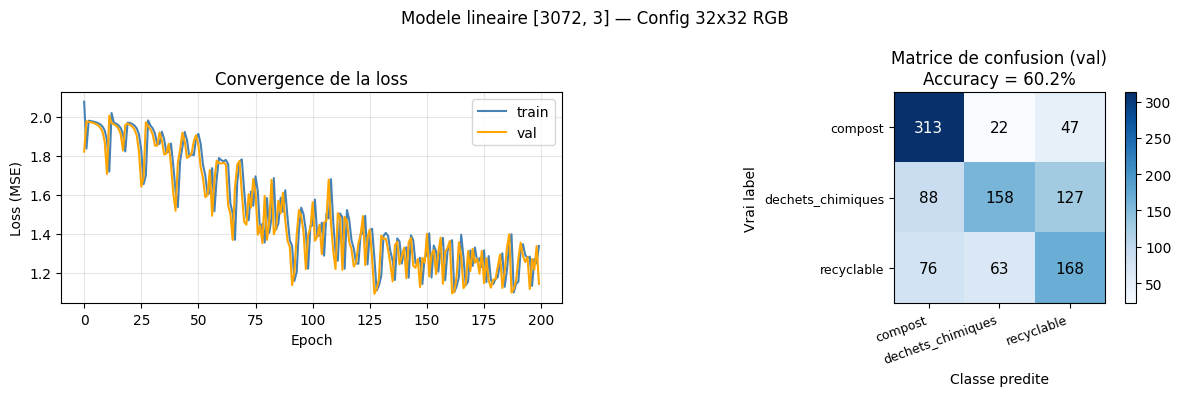

Matrice de confusion (val) :
                            compost  dechets_  recyclab
  compost                      313        22        47
  dechets_chimiques             88       158       127
  recyclable                    76        63       168


In [ ]:
# Visualisation de l'évolution de la loss au cours des epochs

hist_train, hist_val = best_hist

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Modele lineaire [3072, 3] — Config 32x32 RGB", fontsize=12)

# Courbe de convergence de la loss

axes[0].plot(hist_train, color='steelblue', linewidth=1.5, label='train')
axes[0].plot(hist_val,   color='orange',    linewidth=1.5, label='val')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Convergence de la loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Matrice de confusion

cm = best_model.confusion_matrix(X_val, y_val.astype(np.float64))

im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks(range(N_CLASSES))
axes[1].set_yticks(range(N_CLASSES))
axes[1].set_xticklabels(classes, rotation=20, ha='right', fontsize=9)
axes[1].set_yticklabels(classes, fontsize=9)
axes[1].set_xlabel("Classe predite")
axes[1].set_ylabel("Vrai label")
axes[1].set_title(f"Matrice de confusion (val)\nAccuracy = {acc_val*100:.1f}%")

for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        couleur = 'white' if cm[i, j] > cm.max() * 0.6 else 'black'
        axes[1].text(j, i, str(cm[i, j]),
                     ha='center', va='center',
                     color=couleur, fontsize=11)

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("exp_modele_lineaire.png", dpi=130, bbox_inches='tight')
plt.show()

print("Matrice de confusion (val) :")
print(f"{'':25s}", end="")
for c in classes:
    print(f"{c[:8]:>10s}", end="")
print()
for i, c in enumerate(classes):
    print(f"  {c:22s}", end="")
    for j in range(N_CLASSES):
        print(f"{cm[i,j]:>10d}", end="")
    print()

In [9]:
# Essai 2 : PMC avec 8 couches cachées, avec 200 epochs et learning rate = 0.01 [3072, 8, 3]

N_EPOCHS = 200
LR       = 0.01

model_A = PMC([N_FEATURES, 8, N_CLASSES], learning_rate=LR)

hist_train_A = []
hist_val_A   = []

for epoch in range(N_EPOCHS):
    loss_train = model_A.train(X_train, Y_train)
    loss_val   = model_A.loss(X_val, Y_val)
    hist_train_A.append(loss_train)
    hist_val_A.append(loss_val)

acc_train_A = model_A.accuracy(X_train, y_train.astype(np.float64))
acc_val_A   = model_A.accuracy(X_val,   y_val.astype(np.float64))

print(f"Architecture A : [3072, 8, 3]")
print(f"  loss_train : {hist_train_A[-1]:.4f}")
print(f"  loss_val   : {hist_val_A[-1]:.4f}")
print(f"  acc_train  : {acc_train_A*100:.1f}%")
print(f"  acc_val    : {acc_val_A*100:.1f}%")

Architecture A : [3072, 8, 3]
  loss_train : 1.0615
  loss_val   : 1.0485
  acc_train  : 60.7%
  acc_val    : 60.4%


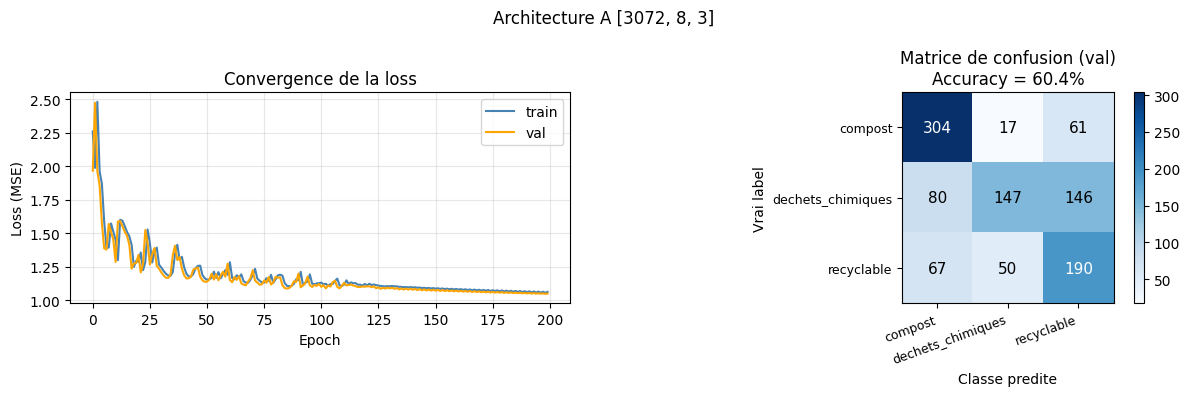

In [ ]:
# Visualisation de l'évolution de la loss au cours des epochs

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Architecture A [3072, 8, 3]", fontsize=12)

# Courbe de loss
axes[0].plot(hist_train_A, color='steelblue', linewidth=1.5, label='train')
axes[0].plot(hist_val_A,   color='orange',    linewidth=1.5, label='val')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Convergence de la loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Matrice de confusion
cm_A = model_A.confusion_matrix(X_val, y_val.astype(np.float64))

im = axes[1].imshow(cm_A, cmap='Blues')
axes[1].set_xticks(range(N_CLASSES))
axes[1].set_yticks(range(N_CLASSES))
axes[1].set_xticklabels(classes, rotation=20, ha='right', fontsize=9)
axes[1].set_yticklabels(classes, fontsize=9)
axes[1].set_xlabel("Classe predite")
axes[1].set_ylabel("Vrai label")
axes[1].set_title(f"Matrice de confusion (val)\nAccuracy = {acc_val_A*100:.1f}%")

for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        couleur = 'white' if cm_A[i, j] > cm_A.max() * 0.6 else 'black'
        axes[1].text(j, i, str(cm_A[i, j]),
                     ha='center', va='center',
                     color=couleur, fontsize=11)

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("exp_3072_8_3.png", dpi=130, bbox_inches='tight')
plt.show()

In [11]:
# Essai 3 : PMC avec 64 couches cachées [3072, 64, 3]

model_B = PMC([N_FEATURES, 64, N_CLASSES], learning_rate=LR)

hist_train_B = []
hist_val_B   = []

for epoch in range(N_EPOCHS):
    loss_train = model_B.train(X_train, Y_train)
    loss_val   = model_B.loss(X_val, Y_val)
    hist_train_B.append(loss_train)
    hist_val_B.append(loss_val)

acc_train_B = model_B.accuracy(X_train, y_train.astype(np.float64))
acc_val_B   = model_B.accuracy(X_val,   y_val.astype(np.float64))

print(f"Architecture B : [3072, 64, 3]")
print(f"  loss_train : {hist_train_B[-1]:.4f}")
print(f"  loss_val   : {hist_val_B[-1]:.4f}")
print(f"  acc_train  : {acc_train_B*100:.1f}%")
print(f"  acc_val    : {acc_val_B*100:.1f}%")

Architecture B : [3072, 64, 3]
  loss_train : 1.0626
  loss_val   : 1.0661
  acc_train  : 60.1%
  acc_val    : 59.9%


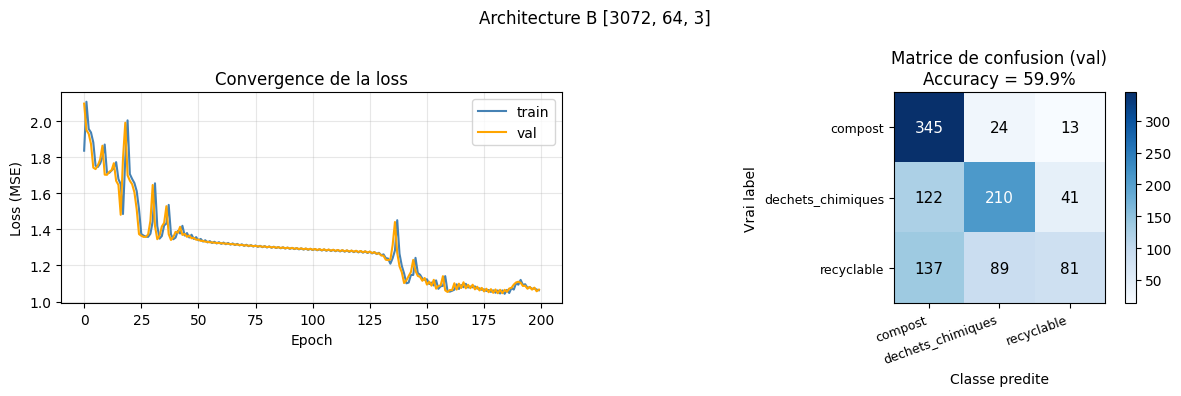

In [ ]:
# Visualisation de l'évolution de la loss au cours des epochs

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Architecture B [3072, 64, 3]", fontsize=12)

axes[0].plot(hist_train_B, color='steelblue', linewidth=1.5, label='train')
axes[0].plot(hist_val_B,   color='orange',    linewidth=1.5, label='val')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Convergence de la loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cm_B = model_B.confusion_matrix(X_val, y_val.astype(np.float64))

im = axes[1].imshow(cm_B, cmap='Blues')
axes[1].set_xticks(range(N_CLASSES))
axes[1].set_yticks(range(N_CLASSES))
axes[1].set_xticklabels(classes, rotation=20, ha='right', fontsize=9)
axes[1].set_yticklabels(classes, fontsize=9)
axes[1].set_xlabel("Classe predite")
axes[1].set_ylabel("Vrai label")
axes[1].set_title(f"Matrice de confusion (val)\nAccuracy = {acc_val_B*100:.1f}%")

for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        couleur = 'white' if cm_B[i, j] > cm_B.max() * 0.6 else 'black'
        axes[1].text(j, i, str(cm_B[i, j]),
                     ha='center', va='center',
                     color=couleur, fontsize=11)

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("exp_3072_64_3.png", dpi=130, bbox_inches='tight')
plt.show()

In [13]:
# Essai 4 : PMC avec 128 couches cachées et 64 couches cachées [3072, 128, 64, 3]

model_C = PMC([N_FEATURES, 128, 64, N_CLASSES], learning_rate=LR)

hist_train_C = []
hist_val_C   = []

for epoch in range(N_EPOCHS):
    loss_train = model_C.train(X_train, Y_train)
    loss_val   = model_C.loss(X_val, Y_val)
    hist_train_C.append(loss_train)
    hist_val_C.append(loss_val)

acc_train_C = model_C.accuracy(X_train, y_train.astype(np.float64))
acc_val_C   = model_C.accuracy(X_val,   y_val.astype(np.float64))

print(f"Architecture C : [3072, 128, 64, 3]")
print(f"  loss_train : {hist_train_C[-1]:.4f}")
print(f"  loss_val   : {hist_val_C[-1]:.4f}")
print(f"  acc_train  : {acc_train_C*100:.1f}%")
print(f"  acc_val    : {acc_val_C*100:.1f}%")

Architecture C : [3072, 128, 64, 3]
  loss_train : 1.0074
  loss_val   : 1.0139
  acc_train  : 61.9%
  acc_val    : 62.1%


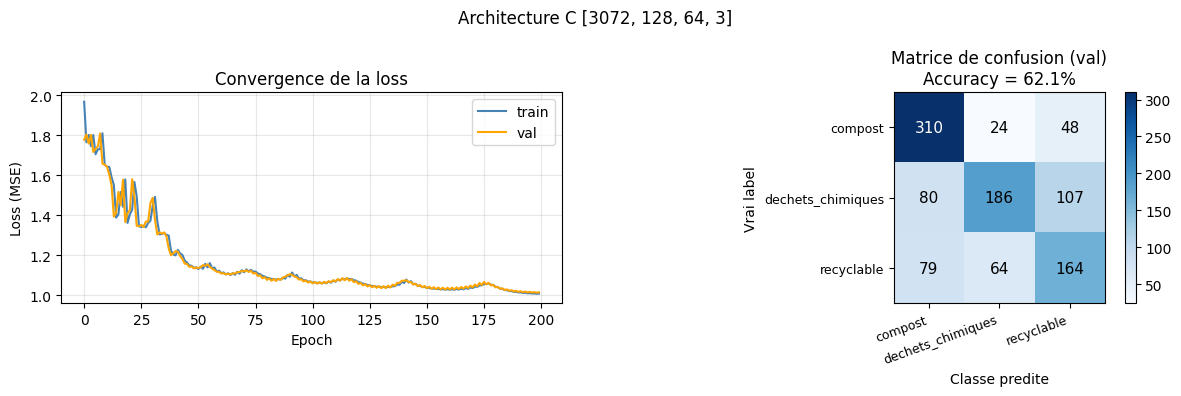

In [ ]:
# Visualisation de l'évolution de la loss au cours des epochs

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Architecture C [3072, 128, 64, 3]", fontsize=12)

axes[0].plot(hist_train_C, color='steelblue', linewidth=1.5, label='train')
axes[0].plot(hist_val_C,   color='orange',    linewidth=1.5, label='val')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Convergence de la loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cm_C = model_C.confusion_matrix(X_val, y_val.astype(np.float64))

im = axes[1].imshow(cm_C, cmap='Blues')
axes[1].set_xticks(range(N_CLASSES))
axes[1].set_yticks(range(N_CLASSES))
axes[1].set_xticklabels(classes, rotation=20, ha='right', fontsize=9)
axes[1].set_yticklabels(classes, fontsize=9)
axes[1].set_xlabel("Classe predite")
axes[1].set_ylabel("Vrai label")
axes[1].set_title(f"Matrice de confusion (val)\nAccuracy = {acc_val_C*100:.1f}%")

for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        couleur = 'white' if cm_C[i, j] > cm_C.max() * 0.6 else 'black'
        axes[1].text(j, i, str(cm_C[i, j]),
                     ha='center', va='center',
                     color=couleur, fontsize=11)

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("exp_3072_128_64_3.png", dpi=130, bbox_inches='tight')
plt.show()

In [16]:
# Essai 5 : PMC avec 256 couches cachées et 128 couches cachées [3072, 256, 128, 3]

model_D = PMC([N_FEATURES, 256, 128, N_CLASSES], learning_rate=LR)

hist_train_D = []
hist_val_D   = []

for epoch in range(N_EPOCHS):
    loss_train = model_D.train(X_train, Y_train)
    loss_val   = model_D.loss(X_val, Y_val)
    hist_train_D.append(loss_train)
    hist_val_D.append(loss_val)

acc_train_D = model_D.accuracy(X_train, y_train.astype(np.float64))
acc_val_D   = model_D.accuracy(X_val,   y_val.astype(np.float64))

print(f"Architecture D : [3072, 256, 128, 3]")
print(f"  loss_train : {hist_train_D[-1]:.4f}")
print(f"  loss_val   : {hist_val_D[-1]:.4f}")
print(f"  acc_train  : {acc_train_D*100:.1f}%")
print(f"  acc_val    : {acc_val_D*100:.1f}%")


Architecture D : [3072, 256, 128, 3]
  loss_train : 1.0300
  loss_val   : 1.0480
  acc_train  : 61.0%
  acc_val    : 60.5%


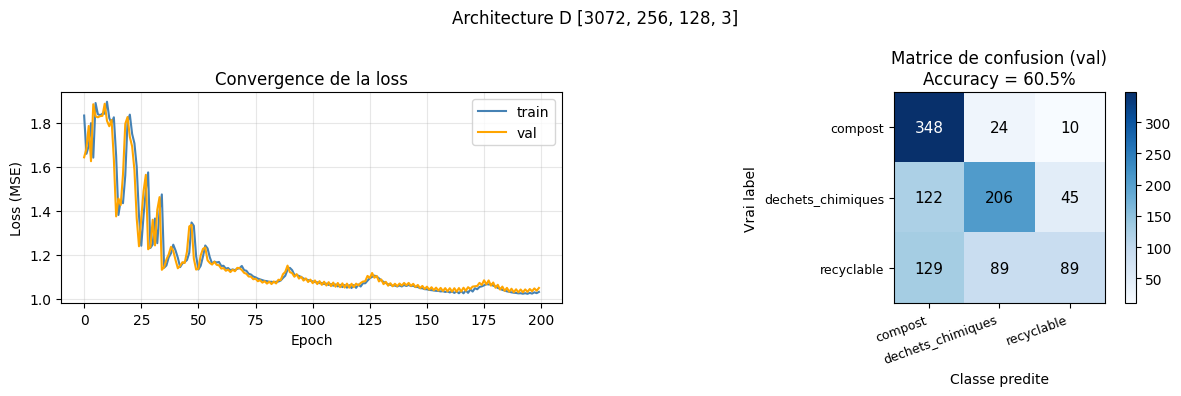

In [42]:
# Visualisation de l'évolution de la loss au cours des epochs

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Architecture D [3072, 256, 128, 3]", fontsize=12)

axes[0].plot(hist_train_D, color='steelblue', linewidth=1.5, label='train')
axes[0].plot(hist_val_D,   color='orange',    linewidth=1.5, label='val')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Convergence de la loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cm_D = model_D.confusion_matrix(X_val, y_val.astype(np.float64))

im = axes[1].imshow(cm_D, cmap='Blues')
axes[1].set_xticks(range(N_CLASSES))
axes[1].set_yticks(range(N_CLASSES))
axes[1].set_xticklabels(classes, rotation=20, ha='right', fontsize=9)
axes[1].set_yticklabels(classes, fontsize=9)
axes[1].set_xlabel("Classe predite")
axes[1].set_ylabel("Vrai label")
axes[1].set_title(f"Matrice de confusion (val)\nAccuracy = {acc_val_D*100:.1f}%")

for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        couleur = 'white' if cm_D[i, j] > cm_D.max() * 0.6 else 'black'
        axes[1].text(j, i, str(cm_D[i, j]),
                     ha='center', va='center',
                     color=couleur, fontsize=11)

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("exp_3072_256_128_3.png", dpi=130, bbox_inches='tight')
plt.show()

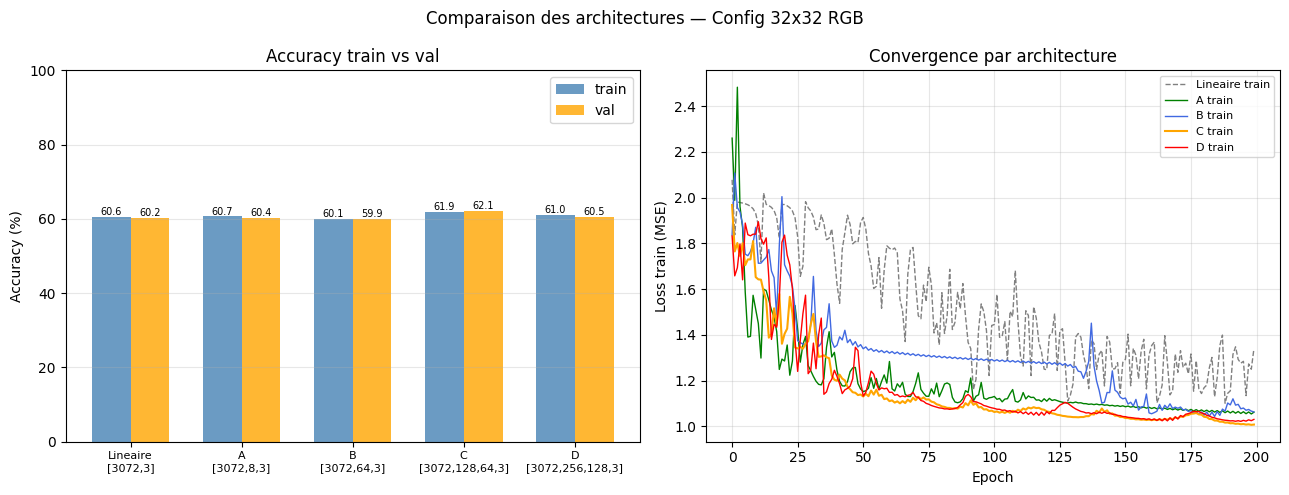

Architecture               acc_train    acc_val      ecart
-------------------------------------------------------
  Lineaire [3072, 3]           60.6%      60.2%      +0.4%
  A [3072, 8, 3]               60.7%      60.4%      +0.3%
  B [3072, 64, 3]              60.1%      59.9%      +0.2%
  C [3072, 128, 64, 3]         61.9%      62.1%      -0.2%
  D [3072, 256, 128, 3]        61.0%      60.5%      +0.4%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Comparaison des architectures — Config 32x32 RGB", fontsize=12)

noms    = ["Lineaire\n[3072,3]", "A\n[3072,8,3]", "B\n[3072,64,3]",
           "C\n[3072,128,64,3]", "D\n[3072,256,128,3]"]
acc_tr  = [acc_train,   acc_train_A, acc_train_B, acc_train_C, acc_train_D]
acc_va  = [acc_val,     acc_val_A,   acc_val_B,   acc_val_C,   acc_val_D]

x = np.arange(len(noms))
w = 0.35

# Graphique en barres accuracy
bars1 = axes[0].bar(x - w/2, [a*100 for a in acc_tr],
                    w, label='train', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + w/2, [a*100 for a in acc_va],
                    w, label='val',   color='orange',    alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(noms, fontsize=8)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy train vs val")
axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}", ha='center', fontsize=7)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}", ha='center', fontsize=7)

# Courbes de loss sur le meme graphique
axes[1].plot(hist_train,   color='gray',      linewidth=1, linestyle='--', label='Lineaire train')
axes[1].plot(hist_train_A, color='green',     linewidth=1, label='A train')
axes[1].plot(hist_train_B, color='royalblue', linewidth=1, label='B train')
axes[1].plot(hist_train_C, color='orange',    linewidth=1.5, label='C train')
axes[1].plot(hist_train_D, color='red',       linewidth=1, label='D train')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss train (MSE)")
axes[1].set_title("Convergence par architecture")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparaison_architectures.png", dpi=130, bbox_inches='tight')
plt.show()

# Tableau recapitulatif

print(f"{'Architecture':<25} {'acc_train':>10} {'acc_val':>10} {'ecart':>10}")
print("-" * 55)
donnees = [
    ("Lineaire [3072, 3]",        acc_train,   acc_val),
    ("A [3072, 8, 3]",            acc_train_A, acc_val_A),
    ("B [3072, 64, 3]",           acc_train_B, acc_val_B),
    ("C [3072, 128, 64, 3]",      acc_train_C, acc_val_C),
    ("D [3072, 256, 128, 3]",     acc_train_D, acc_val_D),
]
for nom, atr, ava in donnees:
    ecart = atr - ava
    print(f"  {nom:<23} {atr*100:>9.1f}% {ava*100:>9.1f}% {ecart*100:>+9.1f}%")

In [19]:
# PMC avec [3072, 128, 64, 3], 100 epochs et un LR de 0.001

N_EPOCHS_LR = 100
LR_A = 0.001

model_lr_A = PMC([N_FEATURES, 128, 64, N_CLASSES], learning_rate=LR_A)

hist_train_lr_A = []
hist_val_lr_A   = []

for epoch in range(N_EPOCHS_LR):
    loss_train = model_lr_A.train(X_train, Y_train)
    loss_val   = model_lr_A.loss(X_val, Y_val)
    hist_train_lr_A.append(loss_train)
    hist_val_lr_A.append(loss_val)

acc_val_lr_A = model_lr_A.accuracy(X_val, y_val.astype(np.float64))

print(f"lr = {LR_A}")
print(f"  loss_train : {hist_train_lr_A[-1]:.4f}")
print(f"  loss_val   : {hist_val_lr_A[-1]:.4f}")
print(f"  acc_val    : {acc_val_lr_A*100:.1f}%")

lr = 0.001
  loss_train : 1.1749
  loss_val   : 1.1672
  acc_val    : 55.7%


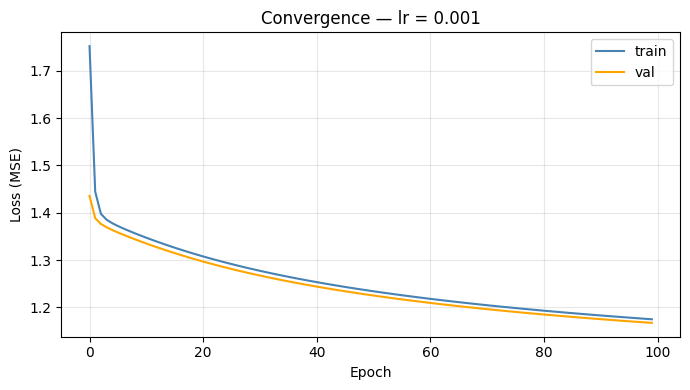

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_train_lr_A, color='steelblue', linewidth=1.5, label='train')
ax.plot(hist_val_lr_A,   color='orange',    linewidth=1.5, label='val')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE)")
ax.set_title("Convergence — lr = 0.001")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("exp_lr_0001.png", dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# PMC avec [3072, 128, 64, 3], 100 epochs et un LR de 0.01

LR_B = 0.01

model_lr_B = PMC([N_FEATURES, 128, 64, N_CLASSES], learning_rate=LR_B)

hist_train_lr_B = []
hist_val_lr_B   = []

for epoch in range(N_EPOCHS_LR):
    loss_train = model_lr_B.train(X_train, Y_train)
    loss_val   = model_lr_B.loss(X_val, Y_val)
    hist_train_lr_B.append(loss_train)
    hist_val_lr_B.append(loss_val)

acc_val_lr_B = model_lr_B.accuracy(X_val, y_val.astype(np.float64))

print(f"lr = {LR_B}")
print(f"  loss_train : {hist_train_lr_B[-1]:.4f}")  
print(f"  loss_val   : {hist_val_lr_B[-1]:.4f}")
print(f"  acc_val    : {acc_val_lr_B*100:.1f}%")

lr = 0.01
  loss_train : 1.0605
  loss_val   : 1.0535
  acc_val    : 59.1%


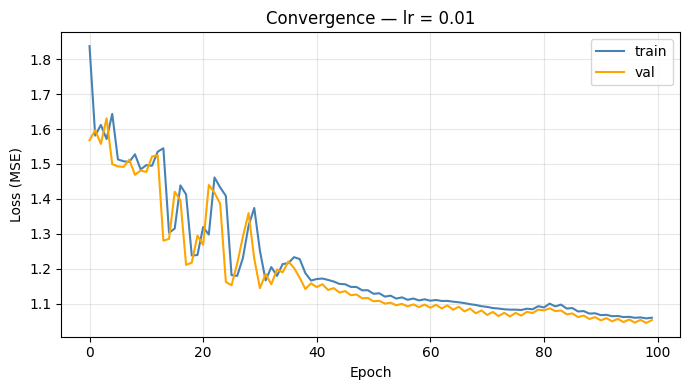

In [ ]:
# Visualisation

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_train_lr_B, color='steelblue', linewidth=1.5, label='train')
ax.plot(hist_val_lr_B,   color='orange',    linewidth=1.5, label='val')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE)")
ax.set_title("Convergence — lr = 0.01")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("exp_lr_001.png", dpi=130, bbox_inches='tight')
plt.show()

In [23]:
# PMC avec [3072, 128, 64, 3], 100 epochs et un LR de 0.05

LR_C = 0.05

model_lr_C = PMC([N_FEATURES, 128, 64, N_CLASSES], learning_rate=LR_C)

hist_train_lr_C = []
hist_val_lr_C   = []

for epoch in range(N_EPOCHS_LR):
    loss_train = model_lr_C.train(X_train, Y_train)
    loss_val   = model_lr_C.loss(X_val, Y_val)
    hist_train_lr_C.append(loss_train)
    hist_val_lr_C.append(loss_val)

acc_val_lr_C = model_lr_C.accuracy(X_val, y_val.astype(np.float64))

print(f"lr = {LR_C}")
print(f"  loss_train : {hist_train_lr_C[-1]:.4f}")
print(f"  loss_val   : {hist_val_lr_C[-1]:.4f}")
print(f"  acc_val    : {acc_val_lr_C*100:.1f}%")

lr = 0.05
  loss_train : 1.4837
  loss_val   : 1.6307
  acc_val    : 44.4%


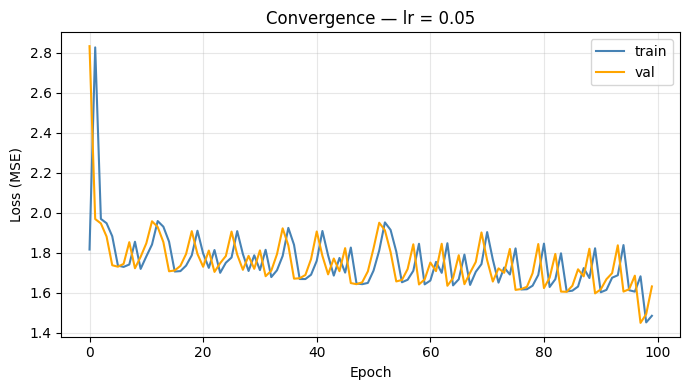

In [ ]:
# Visualisation de la convergence de la loss pour lr = 0.05

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_train_lr_C, color='steelblue', linewidth=1.5, label='train')
ax.plot(hist_val_lr_C,   color='orange',    linewidth=1.5, label='val')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE)")
ax.set_title("Convergence — lr = 0.05")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("exp_lr_005.png", dpi=130, bbox_inches='tight')
plt.show()

In [25]:
# PMC avec [3072, 128, 64, 3], 100 epochs et un LR de 0.005

LR_D = 0.005

model_lr_D = PMC([N_FEATURES, 128, 64, N_CLASSES], learning_rate=LR_D)

hist_train_lr_D = []
hist_val_lr_D   = []

for epoch in range(N_EPOCHS_LR):
    loss_train = model_lr_D.train(X_train, Y_train)
    loss_val   = model_lr_D.loss(X_val, Y_val)
    hist_train_lr_D.append(loss_train)
    hist_val_lr_D.append(loss_val)

acc_val_lr_D = model_lr_D.accuracy(X_val, y_val.astype(np.float64))

print(f"lr = {LR_D}")
print(f"  loss_train : {hist_train_lr_D[-1]:.4f}")
print(f"  loss_val   : {hist_val_lr_D[-1]:.4f}")
print(f"  acc_val    : {acc_val_lr_D*100:.1f}%")

lr = 0.005
  loss_train : 1.0540
  loss_val   : 1.0579
  acc_val    : 59.1%


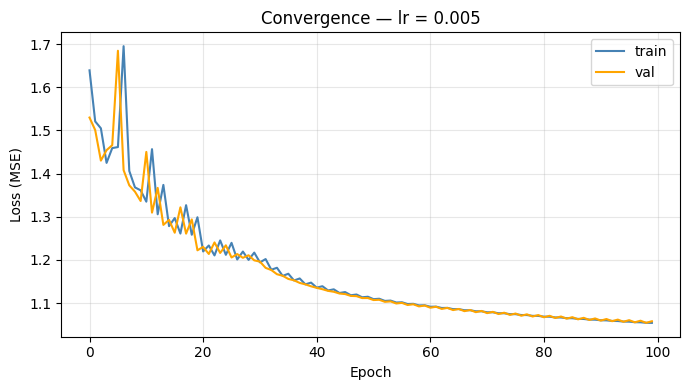

In [ ]:
# Visualisation de l'évolution de la loss au cours des epochs

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_train_lr_D, color='steelblue', linewidth=1.5, label='train')
ax.plot(hist_val_lr_D,   color='orange',    linewidth=1.5, label='val')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE)")
ax.set_title("Convergence — lr = 0.005")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("exp_lr_0005.png", dpi=130, bbox_inches='tight')
plt.show()

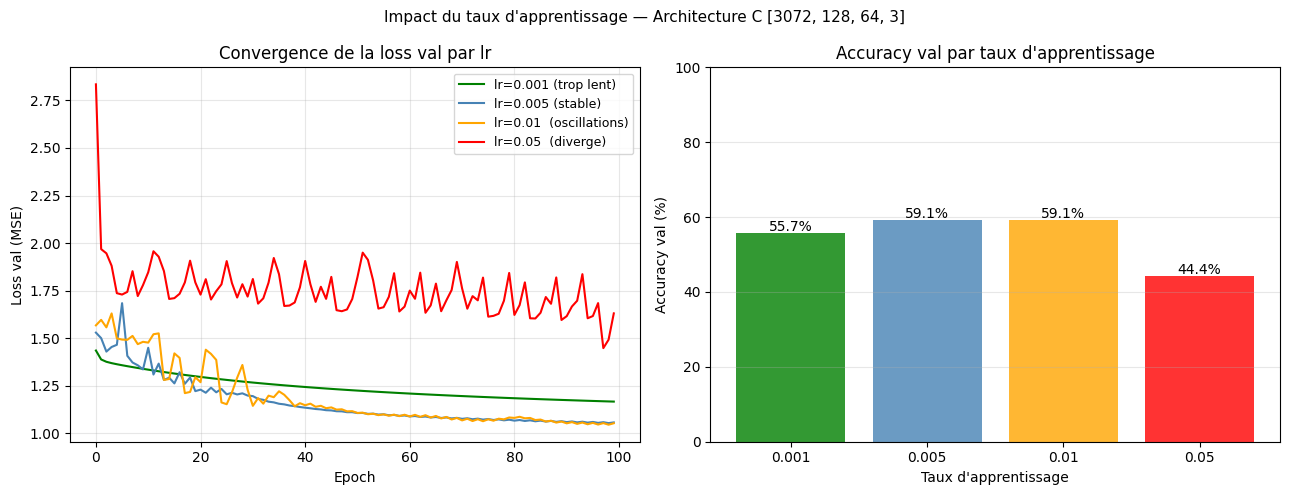

      lr    loss_val     acc_val  comportement
-------------------------------------------------------
   0.001      1.1672       55.7%  trop lent, pas converge
   0.005      1.0579       59.1%  stable, bon compromis
    0.01      1.0535       59.1%  oscillations, converge
    0.05      1.6307       44.4%  diverge


In [ ]:
# Comparaison des courbes de loss val pour les 4 learning rates

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Impact du taux d'apprentissage — Architecture C [3072, 128, 64, 3]",
             fontsize=11)

# Figure gauche : toutes les courbes de loss val

configs_lr = [
    (0.001, hist_val_lr_A, 'green',     'lr=0.001 (trop lent)'),
    (0.005, hist_val_lr_D, 'steelblue', 'lr=0.005 (stable)'),
    (0.01,  hist_val_lr_B, 'orange',    'lr=0.01  (oscillations)'),
    (0.05,  hist_val_lr_C, 'red',       'lr=0.05  (diverge)'),
]

for lr, hist, couleur, label in configs_lr:
    axes[0].plot(hist, color=couleur, linewidth=1.5, label=label)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss val (MSE)")
axes[0].set_title("Convergence de la loss val par lr")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Figure droite : accuracy val par lr

lrs_labels = ['0.001', '0.005', '0.01', '0.05']
accs       = [acc_val_lr_A*100, acc_val_lr_D*100,
              acc_val_lr_B*100, acc_val_lr_C*100]
couleurs   = ['green', 'steelblue', 'orange', 'red']

bars = axes[1].bar(lrs_labels, accs, color=couleurs, alpha=0.8)
axes[1].set_xlabel("Taux d'apprentissage")
axes[1].set_ylabel("Accuracy val (%)")
axes[1].set_title("Accuracy val par taux d'apprentissage")
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{acc:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("exp_comparaison_lr.png", dpi=130, bbox_inches='tight')
plt.show()

# Resume textuel

print(f"{'lr':>8}  {'loss_val':>10}  {'acc_val':>10}  {'comportement'}")
print("-" * 55)
infos = [
    (0.001, hist_val_lr_A[-1], acc_val_lr_A, "trop lent, pas converge"),
    (0.005, hist_val_lr_D[-1], acc_val_lr_D, "stable, bon compromis"),
    (0.01,  hist_val_lr_B[-1], acc_val_lr_B, "oscillations, converge"),
    (0.05,  hist_val_lr_C[-1], acc_val_lr_C, "diverge"),
]
for lr, loss, acc, comportement in infos:
    print(f"  {lr:>6}  {loss:>10.4f}  {acc*100:>9.1f}%  {comportement}")

In [28]:
# Comparaison du nombre d'epochs avec un PMC avec [3072, 128, 64, 3], learning rate = 0.005

N_EPOCHS_MAX = 500

model_epochs = PMC([N_FEATURES, 128, 64, N_CLASSES], learning_rate=0.005)

hist_train_ep = []
hist_val_ep   = []

for epoch in range(N_EPOCHS_MAX):
    loss_train = model_epochs.train(X_train, Y_train)
    loss_val   = model_epochs.loss(X_val, Y_val)
    hist_train_ep.append(loss_train)
    hist_val_ep.append(loss_val)

    if (epoch + 1) % 50 == 0:
        acc = model_epochs.accuracy(X_val, y_val.astype(np.float64))
        print(f"  Epoch {epoch+1:3d} | loss_train={loss_train:.4f} "
              f"loss_val={loss_val:.4f}  acc_val={acc*100:.1f}%")

acc_final = model_epochs.accuracy(X_val, y_val.astype(np.float64))
print(f"\nAccuracy val finale : {acc_final*100:.1f}%")

  Epoch  50 | loss_train=1.1080 loss_val=1.1029  acc_val=58.0%
  Epoch 100 | loss_train=1.0563 loss_val=1.0540  acc_val=59.9%
  Epoch 150 | loss_train=1.0292 loss_val=1.0312  acc_val=60.6%
  Epoch 200 | loss_train=1.0115 loss_val=1.0185  acc_val=61.5%
  Epoch 250 | loss_train=0.9984 loss_val=1.0103  acc_val=61.7%
  Epoch 300 | loss_train=0.9877 loss_val=1.0044  acc_val=61.6%
  Epoch 350 | loss_train=0.9784 loss_val=0.9998  acc_val=62.1%
  Epoch 400 | loss_train=0.9702 loss_val=0.9963  acc_val=62.5%
  Epoch 450 | loss_train=0.9628 loss_val=0.9936  acc_val=62.5%
  Epoch 500 | loss_train=0.9561 loss_val=0.9915  acc_val=62.3%

Accuracy val finale : 62.3%


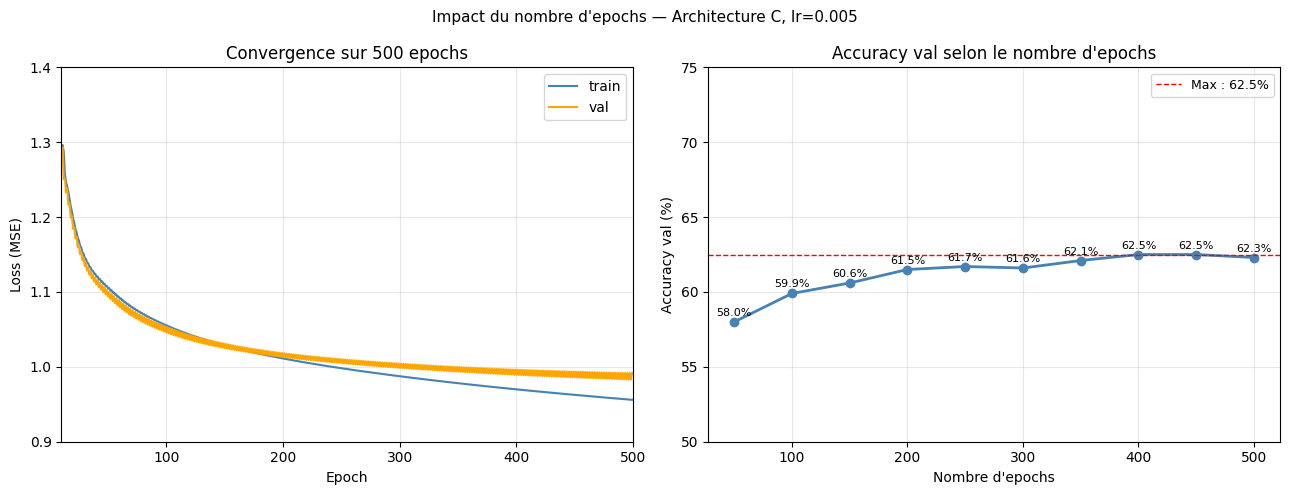

In [ ]:
# Visualisation de l'impact du nombre d'epochs sur la loss et l'accuracy

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Impact du nombre d'epochs — Architecture C, lr=0.005", fontsize=11)

# Courbe de loss complete
axes[0].plot(hist_train_ep, color='steelblue', linewidth=1.5, label='train')
axes[0].plot(hist_val_ep,   color='orange',    linewidth=1.5, label='val')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Convergence sur 500 epochs")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(10, len(hist_train_ep))
axes[0].set_ylim(0.9, 1.4)

# Accuracy par palier
paliers     = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
accs_palier = [58.0, 59.9, 60.6, 61.5, 61.7, 61.6, 62.1, 62.5, 62.5, 62.3]

axes[1].plot(paliers, accs_palier, color='steelblue',
             linewidth=2, marker='o', markersize=6)
axes[1].axhline(y=max(accs_palier), color='red', linestyle='--',
                linewidth=1, label=f"Max : {max(accs_palier):.1f}%")
axes[1].set_xlabel("Nombre d'epochs")
axes[1].set_ylabel("Accuracy val (%)")
axes[1].set_title("Accuracy val selon le nombre d'epochs")
axes[1].set_ylim(50, 75)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

for x, y in zip(paliers, accs_palier):
    axes[1].text(x, y + 0.4, f"{y:.1f}%", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("exp_epochs.png", dpi=130, bbox_inches='tight')
plt.show()

In [34]:
# Essai avec les niveaux de gris

CONFIG = "32x32_gris"

X_train_g, y_train_g, X_val_g, y_val_g, X_test_g, y_test_g, _ = \
    charger_config(CONFIG)

N_FEATURES_G = X_train_g.shape[1]   # 1024

Y_train_g = labels_onehot(y_train_g, N_CLASSES, bipolaire=True)
Y_val_g   = labels_onehot(y_val_g,   N_CLASSES, bipolaire=True)

print(f"Config 32x32 gris charge.")
print(f"N_FEATURES_G = {N_FEATURES_G}  (vs {N_FEATURES} en RGB)")

Config     : 32x32_gris
Classes    : ['compost', 'dechets_chimiques', 'recyclable']
Chargement en cours...

Dimensions :
  X_train : (4961, 1024)  y_train : (4961,)
  X_val   : (1062, 1024)    y_val   : (1062,)
  X_test  : (1065, 1024)   y_test  : (1065,)
  n_features = 1024
  Pixels normalises dans [0, 1] : min=0.000  max=1.000

Repartition par classe :
  compost              : train=1785  val=382  test=384
  dechets_chimiques    : train=1743  val=373  test=373
  recyclable           : train=1433  val=307  test=308

Config 32x32 gris charge.
N_FEATURES_G = 1024  (vs 3072 en RGB)


In [35]:
# PMC avec [1024, 128, 64, 3], 400 epochs et un LR de 0.005

model_gris = PMC([N_FEATURES_G, 128, 64, N_CLASSES], learning_rate=0.005)

hist_train_g = []
hist_val_g_h = []

for epoch in range(400):
    loss_train = model_gris.train(X_train_g, Y_train_g)
    loss_val   = model_gris.loss(X_val_g, Y_val_g)
    hist_train_g.append(loss_train)
    hist_val_g_h.append(loss_val)

    if (epoch + 1) % 100 == 0:
        acc = model_gris.accuracy(X_val_g, y_val_g.astype(np.float64))
        print(f"  Epoch {epoch+1:3d} | loss_train={loss_train:.4f} "
              f"loss_val={loss_val:.4f}  acc_val={acc*100:.1f}%")

acc_gris = model_gris.accuracy(X_val_g, y_val_g.astype(np.float64))
print(f"\nAccuracy val 32x32 gris : {acc_gris*100:.1f}%")
print(f"Accuracy val 32x32 rgb  : 62.5%")
print(f"Difference              : {(acc_gris - 0.625)*100:+.1f}%")

  Epoch 100 | loss_train=1.2747 loss_val=1.2734  acc_val=46.7%
  Epoch 200 | loss_train=1.2523 loss_val=1.2561  acc_val=46.2%
  Epoch 300 | loss_train=1.2386 loss_val=1.2473  acc_val=47.4%
  Epoch 400 | loss_train=1.2279 loss_val=1.2414  acc_val=47.6%

Accuracy val 32x32 gris : 47.6%
Accuracy val 32x32 rgb  : 62.5%
Difference              : -14.9%


In [36]:
# Essai avec les images 64x64 RGB

CONFIG = "64x64_rgb"

X_train_64, y_train_64, X_val_64, y_val_64, X_test_64, y_test_64, _ = \
    charger_config(CONFIG)

N_FEATURES_64 = X_train_64.shape[1]   # 12288

Y_train_64 = labels_onehot(y_train_64, N_CLASSES, bipolaire=True)
Y_val_64   = labels_onehot(y_val_64,   N_CLASSES, bipolaire=True)

print(f"Config 64x64 RGB charge.")
print(f"N_FEATURES_64 = {N_FEATURES_64}")
print(f"  32x32 rgb : 3 072 features")
print(f"  64x64 rgb : 12 288 features  (x4)")

Config     : 64x64_rgb
Classes    : ['compost', 'dechets_chimiques', 'recyclable']
Chargement en cours...

Dimensions :
  X_train : (4961, 12288)  y_train : (4961,)
  X_val   : (1062, 12288)    y_val   : (1062,)
  X_test  : (1065, 12288)   y_test  : (1065,)
  n_features = 12288
  Pixels normalises dans [0, 1] : min=0.000  max=1.000

Repartition par classe :
  compost              : train=1785  val=382  test=384
  dechets_chimiques    : train=1743  val=373  test=373
  recyclable           : train=1433  val=307  test=308

Config 64x64 RGB charge.
N_FEATURES_64 = 12288
  32x32 rgb : 3 072 features
  64x64 rgb : 12 288 features  (x4)


In [37]:
# PMC avec [12288, 128, 64, 3], 400 epochs et un LR de 0.005

model_64 = PMC([N_FEATURES_64, 128, 64, N_CLASSES], learning_rate=0.005)

hist_train_64 = []
hist_val_64   = []

for epoch in range(400):
    loss_train = model_64.train(X_train_64, Y_train_64)
    loss_val   = model_64.loss(X_val_64, Y_val_64)
    hist_train_64.append(loss_train)
    hist_val_64.append(loss_val)

    if (epoch + 1) % 100 == 0:
        acc = model_64.accuracy(X_val_64, y_val_64.astype(np.float64))
        print(f"  Epoch {epoch+1:3d} | loss_train={loss_train:.4f} "
              f"loss_val={loss_val:.4f}  acc_val={acc*100:.1f}%")

acc_64 = model_64.accuracy(X_val_64, y_val_64.astype(np.float64))
print(f"\nAccuracy val 64x64 rgb  : {acc_64*100:.1f}%")
print(f"Accuracy val 32x32 rgb  : 62.5%")
print(f"Difference              : {(acc_64 - 0.625)*100:+.1f}%")

  Epoch 100 | loss_train=1.0869 loss_val=1.0809  acc_val=58.4%
  Epoch 200 | loss_train=1.0006 loss_val=1.0106  acc_val=62.3%
  Epoch 300 | loss_train=0.9717 loss_val=0.9892  acc_val=62.1%
  Epoch 400 | loss_train=0.9739 loss_val=1.0297  acc_val=61.5%

Accuracy val 64x64 rgb  : 61.5%
Accuracy val 32x32 rgb  : 62.5%
Difference              : -1.0%


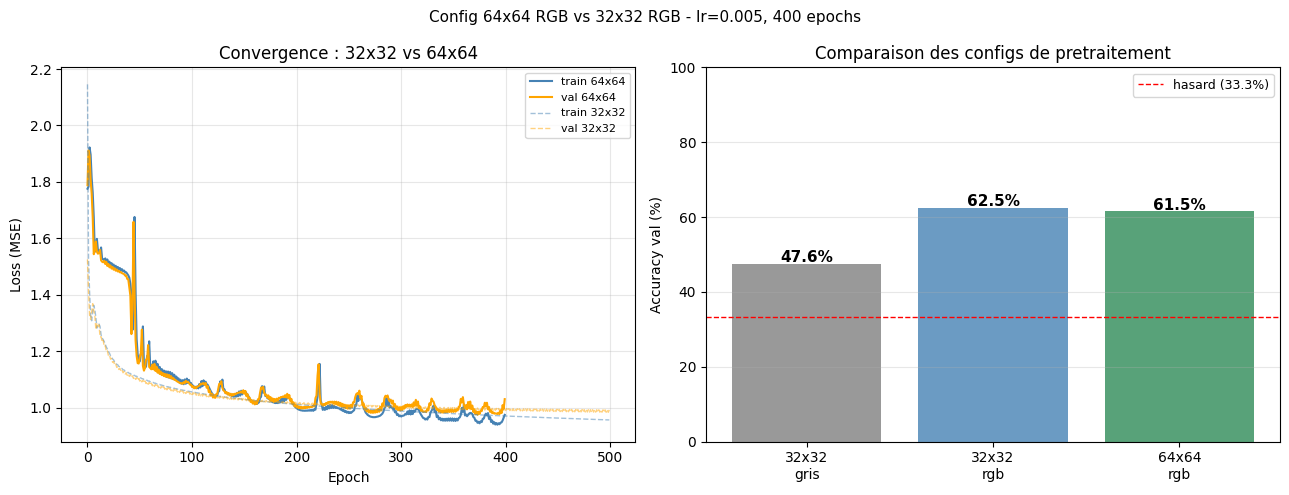

Synthese des configs :
  32x32 gris : 47.6%  <- couleur essentielle
  32x32 rgb  : 62.5%  <- meilleur compromis
  64x64 rgb  : 61.5%  <- sur-apprentissage, besoin de plus de donnees


In [ ]:
# Visualisation de la convergence de la loss pour les 2 configurations

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Config 64x64 RGB vs 32x32 RGB - lr=0.005, 400 epochs",
             fontsize=11)

# Courbes de loss
axes[0].plot(hist_train_64, color='steelblue', linewidth=1.5, label='train 64x64')
axes[0].plot(hist_val_64,   color='orange',    linewidth=1.5, label='val 64x64')
axes[0].plot(hist_train_ep, color='steelblue', linewidth=1,
             linestyle='--', alpha=0.5, label='train 32x32')
axes[0].plot(hist_val_ep,   color='orange',    linewidth=1,
             linestyle='--', alpha=0.5, label='val 32x32')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Convergence : 32x32 vs 64x64")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Comparaison des configs
configs  = ["32x32\ngris", "32x32\nrgb", "64x64\nrgb"]
accs     = [47.6, 62.5, 61.5]
couleurs = ['gray', 'steelblue', 'seagreen']

bars = axes[1].bar(configs, accs, color=couleurs, alpha=0.8)
axes[1].set_ylabel("Accuracy val (%)")
axes[1].set_title("Comparaison des configs de pretraitement")
axes[1].set_ylim(0, 100)
axes[1].axhline(y=33.3, color='red', linestyle='--',
                linewidth=1, label='hasard (33.3%)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{acc:.1f}%", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("exp_configs.png", dpi=130, bbox_inches='tight')
plt.show()

print("Synthese des configs :")
print(f"  32x32 gris : 47.6%  <- couleur essentielle")
print(f"  32x32 rgb  : 62.5%  <- meilleur compromis")
print(f"  64x64 rgb  : 61.5%  <- sur-apprentissage, besoin de plus de donnees")

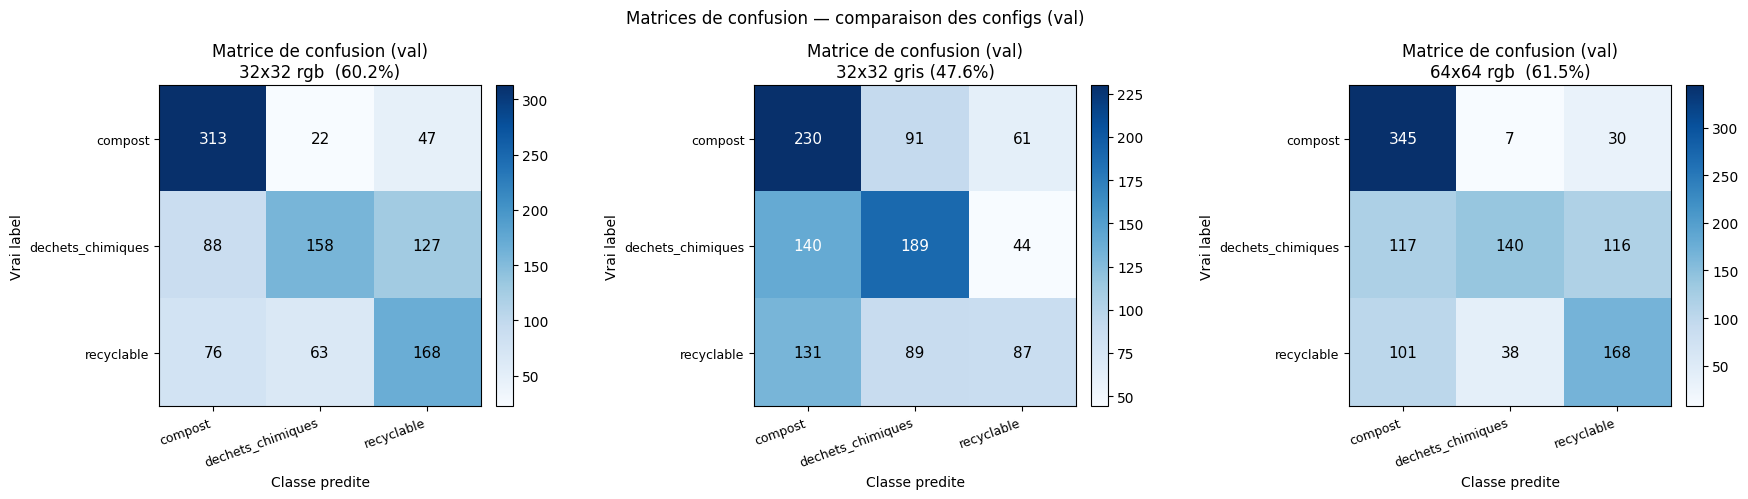

In [41]:
# Matrices de confusion pour les 3 configurations

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Matrices de confusion — comparaison des configs (val)", fontsize=12)

configs_cm = [
    (best_model, X_val,   y_val,   f"32x32 rgb  ({acc_val*100:.1f}%)"),
    (model_gris, X_val_g, y_val_g, f"32x32 gris ({acc_gris*100:.1f}%)"),
    (model_64,   X_val_64,y_val_64,f"64x64 rgb  ({acc_64*100:.1f}%)"),
]

for ax, (model, X_v, y_v, titre) in zip(axes, configs_cm):
    cm = model.confusion_matrix(X_v, y_v.astype(np.float64))

    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(N_CLASSES))
    ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(classes, rotation=20, ha='right', fontsize=9)
    ax.set_yticklabels(classes, fontsize=9)
    ax.set_xlabel("Classe predite")
    ax.set_ylabel("Vrai label")
    ax.set_title(f"Matrice de confusion (val)\n{titre}")

    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            couleur = 'white' if cm[i, j] > cm.max() * 0.6 else 'black'
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center',
                    color=couleur, fontsize=11)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("exp_matrices_confusion_all.png", dpi=130, bbox_inches='tight')
plt.show()